**practica #2:**

**Introducción a Python y Señales y Sistemas Discretos**

**presentado por:**
Karly Tarazona, Luis Montoya 


**procedimiento**

1. A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.stats as stats
from scipy.signal import find_peaks

# Cargar el archivo .mat
data = sio.loadmat(r"C:\Users\Acer\Desktop\Biosenales_Luis_Montoya\Biosenales_Luis_Montoya_Karly_Tarazona-1\signals.mat")
print(data.keys())

ecg = data["ECG_asRecording"].flatten() 
ecg_filtered = data['ECG_filtered'].flatten()
fs = data['Fs'][0][0] # Frecuencia de muestreo en Hz

# Calcular el número de muestras
n_muestras = len(ecg_raw)

# Crear el vector de tiempo
duracion = n_muestras / fs
tiempo = np.linspace(0, duracion, n_muestras, endpoint=False)

print(f"---Duración de la señal: {duracion} segundos---")

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
---Duración de la señal: 30.0 segundos---


2. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

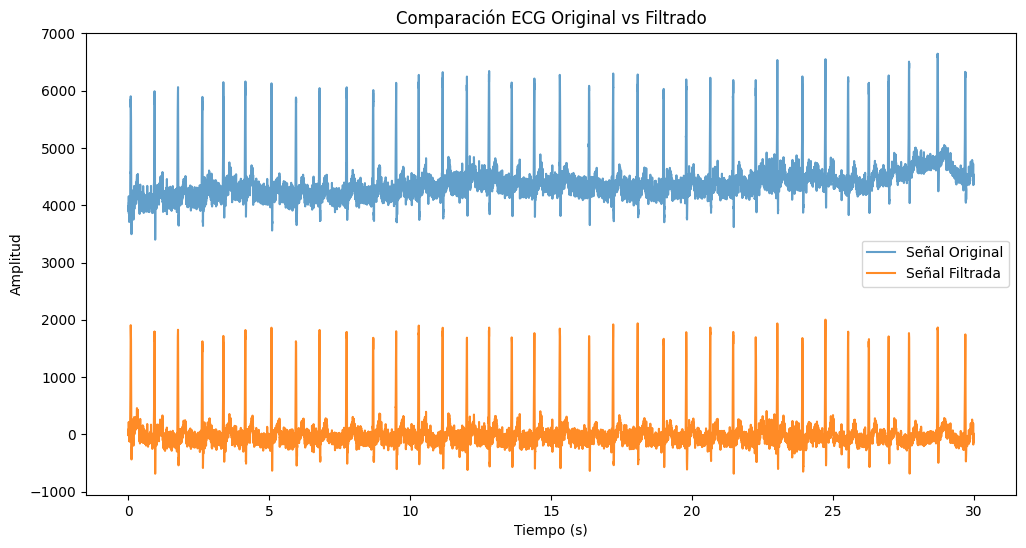

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(tiempo, ecg, label='Señal Original', alpha=0.7)
plt.plot(tiempo, ecg_filtered, label='Señal Filtrada', alpha=0.9)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Comparación ECG Original vs Filtrado')
plt.legend()
plt.show()

Análisis esperado: Debes observar la señal gráfica e identificar qué ruidos se atenuaron. Comúnmente, el filtro aplicado suele ser un filtro pasa-banda (para eliminar el ruido de baja frecuencia como la deriva de la línea base por respiración) o un filtro Notch (para eliminar la interferencia de la red eléctrica a 60 Hz).

3. Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.Repita lo mismo con la señal filtrada y compare

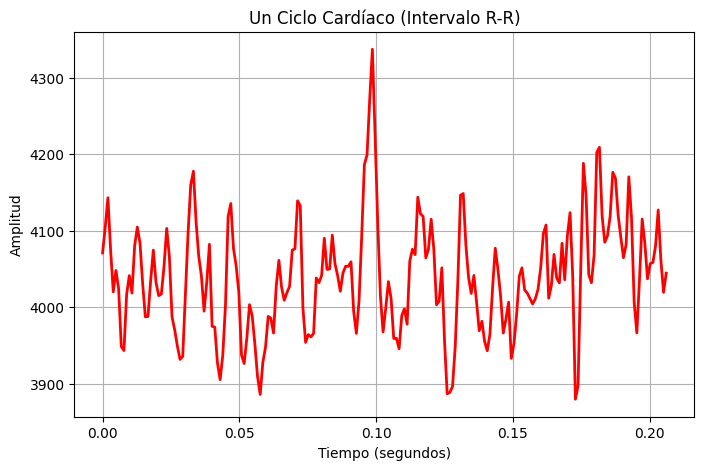

--- Estadísticas Ciclo Original ---
Promedio: 4048.5600
RMS: 4049.3123
Varianza: 6091.5926
Desviación Estándar: 78.0487



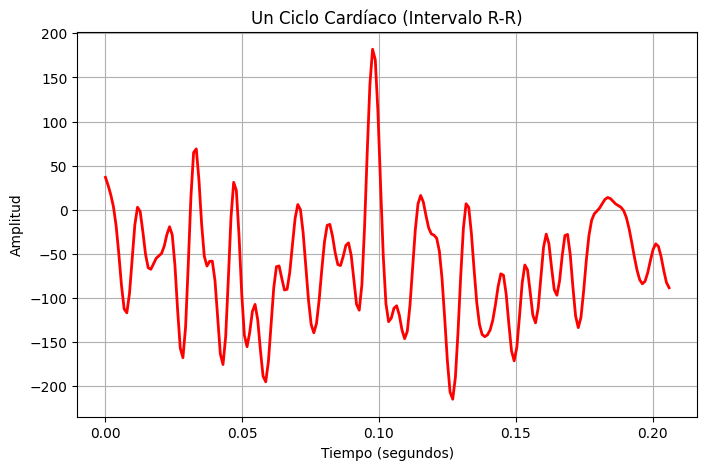

--- Estadísticas Ciclo Filtrado ---
Promedio: -44.2769
RMS: 85.9862
Varianza: 5433.1834
Desviación Estándar: 73.7101



In [ ]:
# Definir índices de inicio y fin para un ciclo
inicio, fin = 500, 800 # Ajusta estos índices según tu señal

ciclo_ECG = ecg[inicio:fin]
ciclo_filt = ecg_filtered[inicio:fin]

def calcular_estadisticas(ciclo, nombre):
    promedio = np.mean(ciclo)
    rms = np.sqrt(np.mean(ciclo**2))
    varianza = np.var(ciclo)
    desviacion = np.std(ciclo)
# 1. Encontrar los picos R en la señal
# Se usa el parámetro 'distance' para evitar detectar falsos picos muy juntos.
# Asumimos que la frecuencia cardíaca máxima no supera los 150 lpm (aprox 0.4 segundos entre latidos)
    distancia_minima = int(0.4 * fs) 
    picos, _ = find_peaks(ecg, distance=distancia_minima)

# 2. Seleccionar un ciclo cardíaco (entre el primer y el segundo pico detectado)
    indice_inicio = picos[0]
    indice_fin = picos[1]

# Recortar la señal
    ciclo_cardiaco = ciclo[indice_inicio:indice_fin]

# Crear un vector de tiempo específico para este ciclo
    tiempo_ciclo = np.linspace(0, len(ciclo_cardiaco)/fs, len(ciclo_cardiaco), endpoint=False)

# 3. Graficar el ciclo seleccionado
    plt.figure(figsize=(8, 5))
    plt.plot(tiempo_ciclo, ciclo_cardiaco, color='red', linewidth=2)
    plt.title('Un Ciclo Cardíaco (Intervalo R-R)')
    plt.xlabel('Tiempo (segundos)') 
    plt.ylabel('Amplitud')
    plt.grid(True)
    plt.show()
    
    print(f"--- Estadísticas {nombre} ---")
    print(f"Promedio: {promedio:.4f}")
    print(f"RMS: {rms:.4f}")
    print(f"Varianza: {varianza:.4f}")
    print(f"Desviación Estándar: {desviacion:.4f}\n")



calcular_estadisticas(ciclo_ECG, "Ciclo Original")
calcular_estadisticas(ciclo_filt, "Ciclo Filtrado")

commparacion

4. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?

--- Resultados Estadísticos por Ciclo ---
Ciclo 1 -> Promedio: 74.0100 | Varianza: 96684.3149
Ciclo 2 -> Promedio: -1.4626 | Varianza: 104790.4655
Ciclo 3 -> Promedio: -10.4330 | Varianza: 82451.2511
Ciclo 4 -> Promedio: -20.9752 | Varianza: 46839.0197
Ciclo 5 -> Promedio: 40.8711 | Varianza: 114850.0201
Ciclo 6 -> Promedio: -27.9437 | Varianza: 58147.5895
Ciclo 7 -> Promedio: 0.4308 | Varianza: 77707.2812
Ciclo 8 -> Promedio: 21.4079 | Varianza: 100268.1815
Ciclo 9 -> Promedio: -10.1753 | Varianza: 71784.9558
Ciclo 10 -> Promedio: 8.8121 | Varianza: 68481.0598
Ciclo 11 -> Promedio: -8.9062 | Varianza: 76088.3849
Ciclo 12 -> Promedio: 13.2133 | Varianza: 93862.6959
Ciclo 13 -> Promedio: -4.2033 | Varianza: 87951.5045
Ciclo 14 -> Promedio: -14.9697 | Varianza: 77022.1329
Ciclo 15 -> Promedio: 27.1083 | Varianza: 89636.9356


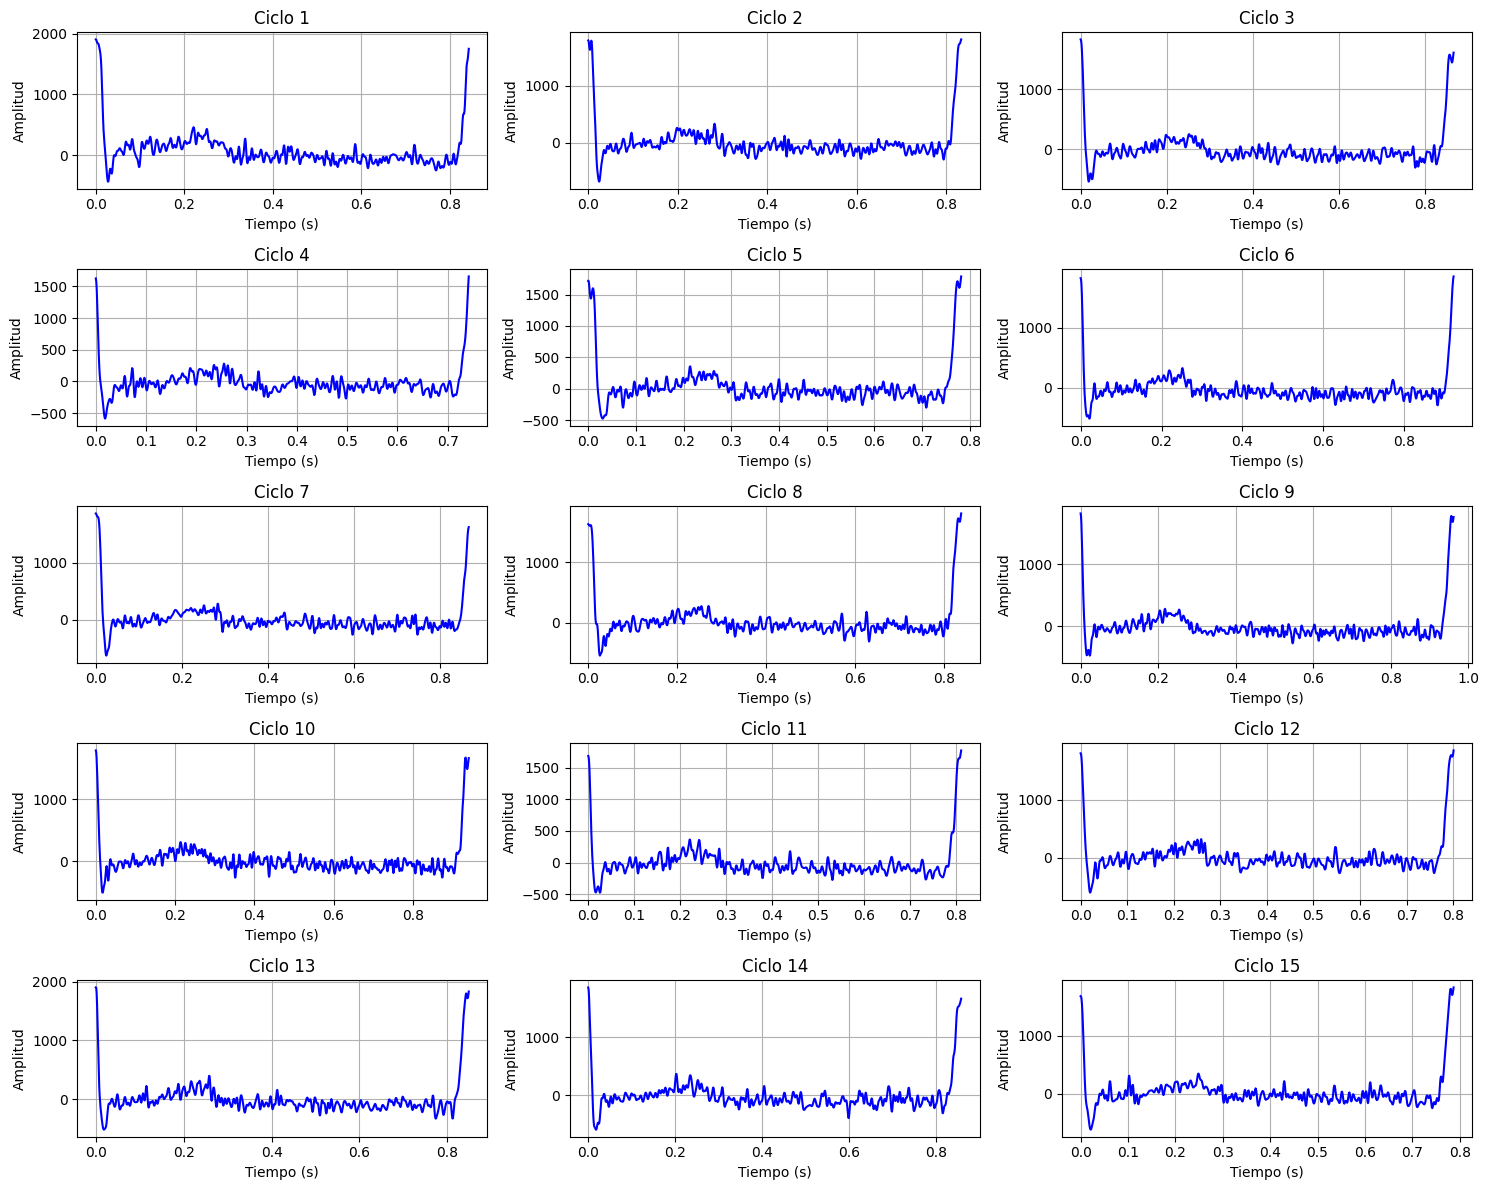

In [27]:

picos_r, _ = find_peaks(ecg_filtered, distance=fs*0.6) # Asumiendo un mínimo de 0.6s entre latidos

ciclos = []
medias = []
varianzas = []

# Extraer los primeros 15 ciclos
for i in range(15):
    ciclo_actual = ecg_filtered[picos_r[i]:picos_r[i+1]]
    ciclos.append(ciclo_actual)
    medias.append(np.mean(ciclo_actual))
    varianzas.append(np.var(ciclo_actual))

print("--- Resultados Estadísticos por Ciclo ---")
for i in range(15):
    print(f"Ciclo {i+1} -> Promedio: {medias[i]:.4f} | Varianza: {varianzas[i]:.4f}")


# Crear una figura grande con una cuadrícula de 5x3 para los 15 ciclos
fig, axes = plt.subplots(5, 3, figsize=(15, 12))

# Aplanar la matriz de ejes para poder iterar sobre ella fácilmente (del 0 al 14)
axes = axes.flatten()

# Iterar sobre los 15 ciclos guardados
for i in range(15):
    ciclo_actual = ciclos[i]
    
    # Crear un vector de tiempo específico para la longitud de cada ciclo
    t_ciclo = np.linspace(0, len(ciclo_actual)/fs, len(ciclo_actual), endpoint=False)
    
    # Graficar en su respectivo recuadro
    axes[i].plot(t_ciclo, ciclo_actual, color='blue')
    axes[i].set_title(f'Ciclo {i+1}')
    axes[i].set_xlabel('Tiempo (s)')
    axes[i].set_ylabel('Amplitud')
    axes[i].grid(True)

# Ajustar automáticamente los espacios para que los textos no se superpongan
plt.tight_layout()
plt.show()


5. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).

6. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad)